Best K: 3 silhouette: 0.185


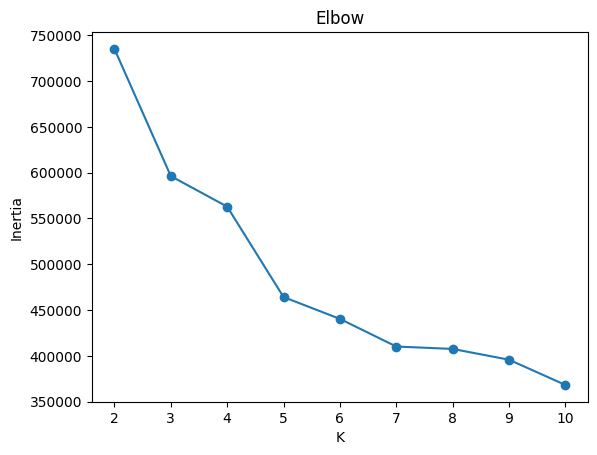

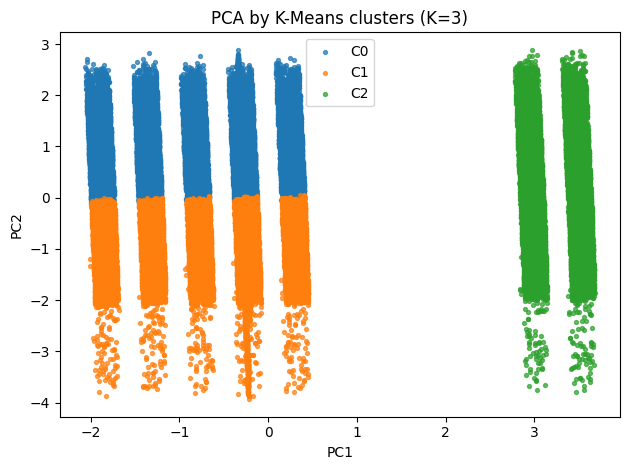

C:\Users\Beckh\AppData\Local\Temp\ipykernel_31412\1143278528.py:107: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)


,"(Age, count)","(Age, mean)","(Age, median)","(Police involvement, count)","(Police involvement, mean)","(Police involvement, median)",Race=Asian/Pacific Islander,Race=Black,Race=Hispanic,Race=Native American/Native Alaskan,...,Reason=Undetermined,AgeBucket=<=17,AgeBucket=18-25,AgeBucket=26-35,AgeBucket=36-45,AgeBucket=46-55,AgeBucket=56-65,AgeBucket=66+,Sex=Female,Sex=Male
cluster,,,,,,,,,,,,,,,,,,,,,
0,44549,60.46,59.0,44553,0.00,0.0,0.009,0.035,0.028,0.005,...,0.007,0.000,0.000,0.000,0.136,0.273,0.262,0.329,0.157,0.843
1,43868,29.08,28.0,43881,0.03,0.0,0.018,0.431,0.151,0.013,...,0.010,0.054,0.347,0.386,0.159,0.047,0.006,0.000,0.129,0.871
2,12363,44.64,42.0,12364,0.01,0.0,0.013,0.231,0.091,0.010,...,0.006,0.026,0.171,0.198,0.152,0.156,0.132,0.164,0.144,0.856


In [1]:
# import libraries
import pandas as pd, numpy as np
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# import dataset
file_path = "../data/raw/Guns incident Data.csv"
df = pd.read_csv(file_path)

# basic cleaning (can remove and import cleaned dataset later)
df = df.replace({"NA": np.nan}) # replace NA
df["Age"] = pd.to_numeric(df["Age"], errors = "coerce")
df["Police involvement"] = pd.to_numeric(df["Police involvement"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# columns to keep
useful_cols = ["Date", "Reason", "Education", "Sex", "Age", "Race", "Place of incident", "Police involvement"]
df_copy = df[useful_cols].copy()

# --- Feature Engineering ---
bins = [-np.inf, 17, 25, 35, 45, 55, 65, np.inf]
labels = ["<=17","18-25","26-35","36-45","46-55","56-65","66+"]
df_copy["AgeBucket"] = pd.cut(df_copy["Age"], bins=bins, labels=labels)  # <-- use AgeBucket consistently

df_copy["Month"]   = df_copy["Date"].dt.month
df_copy["Weekday"] = df_copy["Date"].dt.weekday
df_copy["IsWeekend"] = df_copy["Weekday"].isin([5,6]).astype("float")

def combine_small_categories(s: pd.Series, min_count=700, other_label="Other"):
    counts = s.value_counts(dropna=True)
    keep = counts[counts >= min_count].index
    return s.where(s.isin(keep), other_label)

for col in ["Race","Education","Place of incident","Reason"]:
    df_copy[col] = combine_small_categories(df_copy[col], min_count=700)

# final feature set (match names exactly)
cat_features = ["Race","Education","Place of incident","Reason","AgeBucket","Sex"]
num_features = ["Age","Month","Weekday","IsWeekend","Police involvement"]

df_cluster = df_copy[cat_features + num_features].copy()

# --- Preprocess ---
cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh" , OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # if older sklearn, use sparse=False
])

num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc" , StandardScaler())
])

# Use the SAME variable names you defined above
pre = ColumnTransformer([
    ("cat", cat_pipeline, cat_features),
    ("num", num_pipeline, num_features)
], remainder="drop")

# --- Pick K (silhouette + elbow) and fit K-Means ---
df_pre = pre.fit_transform(df_cluster)

best_k, best_score, scores = None, -1, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    labels = km.fit_predict(df_pre)
    s = silhouette_score(df_pre, labels)
    scores[k] = s
    if s > best_score:
        best_k, best_score = k, s
print("Best K:", best_k, "silhouette:", round(best_score,3))

inertias = []
for k in range(2, 11):
    inertias.append(KMeans(n_clusters=k, n_init="auto", random_state=3244).fit(df_pre).inertia_)
plt.plot(range(2,11), inertias, marker="o"); plt.title("Elbow"); plt.xlabel("K"); plt.ylabel("Inertia"); plt.show()

kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=3244)
labels = kmeans.fit_predict(df_pre)

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1":X_2d[:,0], "PC2":X_2d[:,1], "cluster":labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster==c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend(); plt.title(f"PCA by K-Means clusters (K={best_k})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

# --- Cluster Profile Table ---
prof = df_copy.copy()
prof["cluster"] = labels

num_summary = prof.groupby("cluster")[["Age","Police involvement"]].agg(["count","mean","median"]).round(2)

def prop_table(col):
    tab = (prof.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

cat_summary = pd.concat([prop_table(c) for c in ["Race","Education","Place of incident","Reason","AgeBucket","Sex"]], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()
cluster_profile.head()



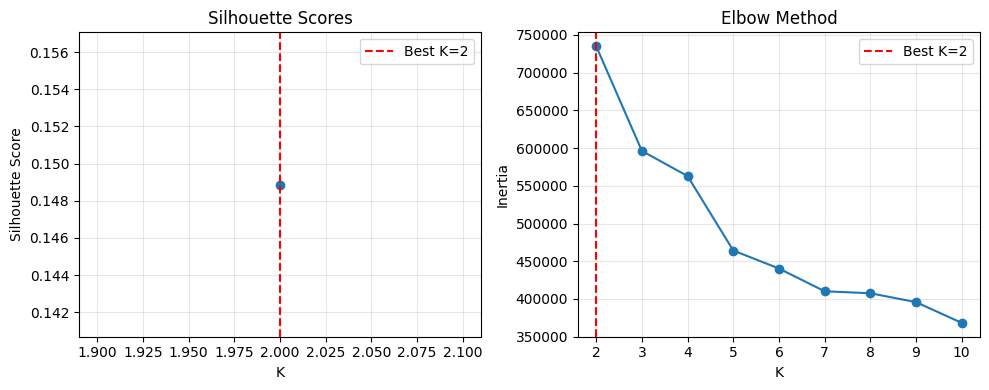


=== K-Means with K=5 ===


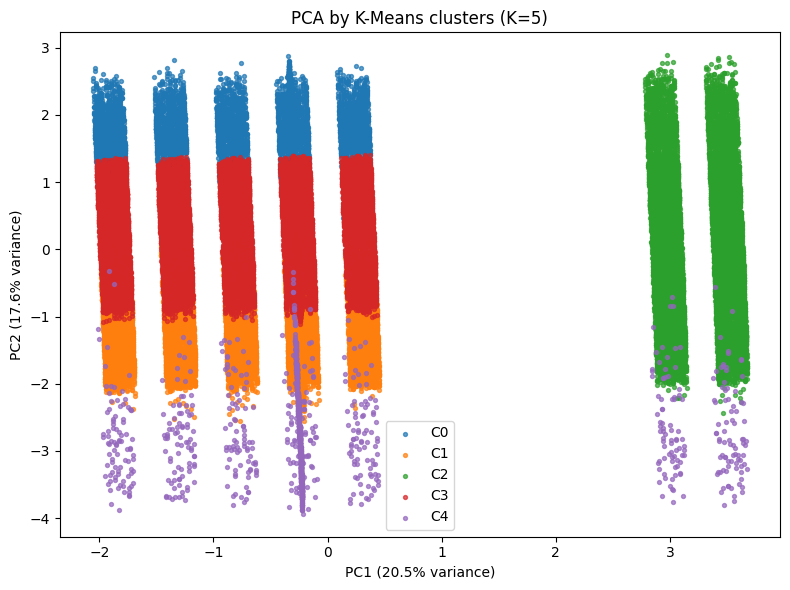


=== K-Means with K=6 ===


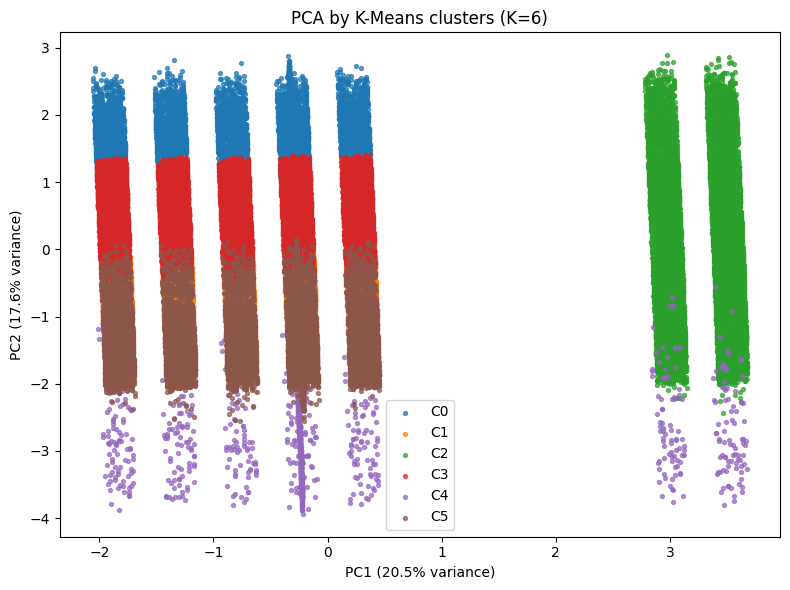


=== Cluster Profile for K=5 ===

Cluster sizes:
cluster
0    14654
1    28936
2    12199
3    43607
4     1402
Name: count, dtype: int64

=== Cluster Profile for K=6 ===

Cluster sizes:
cluster
0    14653
1    15860
2    12199
3    32304
4     1402
5    24380
Name: count, dtype: int64


C:\Users\Beckh\AppData\Local\Temp\ipykernel_31412\2976649809.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof_k.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
C:\Users\Beckh\AppData\Local\Temp\ipykernel_31412\2976649809.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof_k.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)



=== COMPLETE Cluster Profile for K=5 ===
         (Age, count)  (Age, mean)  (Age, median)  \
cluster                                             
0               14654        76.57           75.0   
1               28928        28.96           27.0   
2               12198        44.76           42.0   
3               43598        45.02           47.0   
4                1402        37.05           35.0   

         (Police involvement, count)  (Police involvement, mean)  \
cluster                                                            
0                              14654                         0.0   
1                              28936                         0.0   
2                              12199                         0.0   
3                              43607                         0.0   
4                               1402                         1.0   

         (Police involvement, median)  Race=Asian/Pacific Islander  \
cluster                                

In [5]:
# --- Additional analysis for k=5 and k=6 ---

# Recalculate inertias to ensure we have all values
inertias = []
for k in range(2, 11):
    km_temp = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    km_temp.fit(df_pre)
    inertias.append(km_temp.inertia_)

# Plot silhouette scores and elbow
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.title('Silhouette Scores')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), inertias, marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Function to plot PCA for a given k
def plot_kmeans_pca(k, df_pre, pca_model, X_2d):
    km = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    labels_k = km.fit_predict(df_pre)
    
    plot_df_k = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "cluster": labels_k})
    
    plt.figure(figsize=(8, 6))
    for c in sorted(plot_df_k.cluster.unique()):
        sub = plot_df_k[plot_df_k.cluster == c]
        plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
    plt.legend()
    plt.title(f"PCA by K-Means clusters (K={k})")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.tight_layout()
    plt.show()
    
    return labels_k

# Plot for k=5
print("\n=== K-Means with K=5 ===")
labels_5 = plot_kmeans_pca(5, df_pre, pca, X_2d)

# Plot for k=6
print("\n=== K-Means with K=6 ===")
labels_6 = plot_kmeans_pca(6, df_pre, pca, X_2d)

# Optional: Create cluster profiles for k=5 and k=6
def create_cluster_profile(labels_k, k_value):
    prof_k = df_copy.copy()
    prof_k["cluster"] = labels_k
    
    print(f"\n=== Cluster Profile for K={k_value} ===")
    print(f"\nCluster sizes:")
    print(prof_k["cluster"].value_counts().sort_index())
    
    num_summary_k = prof_k.groupby("cluster")[["Age", "Police involvement"]].agg(["count", "mean", "median"]).round(2)
    
    cat_summary_k = pd.concat([prop_table_k(c, prof_k) for c in ["Race", "Education", "Place of incident", "Reason", "AgeBucket", "Sex"]], axis=1)
    
    cluster_profile_k = pd.concat([num_summary_k, cat_summary_k], axis=1).sort_index()
    return cluster_profile_k

def prop_table_k(col, prof_k):
    tab = (prof_k.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

# Generate profiles
profile_5 = create_cluster_profile(labels_5, 5)
profile_6 = create_cluster_profile(labels_6, 6)

# Display full profiles
print("\n=== COMPLETE Cluster Profile for K=5 ===")
print(profile_5)

print("\n=== COMPLETE Cluster Profile for K=6 ===")
print(profile_6)

# Summary

## Summary of K-Means Clustering Results
### K=5 Clustering
Cluster Characteristics:

**Cluster 0 (n=14,654 - 15%) - Elderly Suicide Victims**

Age: Mean 76.6 years, all 66+ years old
Demographics: 89% Male, predominantly White (93%)
Key Feature: Oldest cluster, represents senior citizens
Police Involvement: 0%

**Cluster 1 (n=28,936 - 29%) - Young Black Homicide Victims**

Age: Mean 29.0 years (56% are 18-25, 34% are 26-35)
Demographics: 88% Male, 63% Black, 19% Hispanic
Key Feature: Youngest cluster with highest proportion of Black victims
Police Involvement: 0%

**Cluster 2 (n=12,199 - 12%) - Middle-Aged Mixed Demographics**

Age: Mean 44.8 years (fairly evenly distributed across 26-65)
Demographics: 86% Male, 23% Black, 65% White
Key Feature: Most age-diverse cluster
Police Involvement: 0%

**Cluster 3 (n=43,607 - 43%) - Middle-Aged White Suicide Victims**

Age: Mean 45.0 years (peak at 46-65 age range)
Demographics: 83% Male, predominantly White (91%)
Key Feature: Largest cluster, mainly middle-aged White males
Police Involvement: 0%

**Cluster 4 (n=1,402 - 1%) - Police-Involved Shootings**

Age: Mean 37.1 years (31% are 26-35, 23% are 36-45)
Demographics: 96% Male, 25% Black, 20% Hispanic, 49% White
Key Feature: ONLY cluster with police involvement (100%)
Police Involvement: 100%

### K=6 Clustering
K=6 essentially splits Cluster 1 from K=5 into two groups:
New Cluster 1 (n=15,860) - Very Young Victims

Age: Mean 26.0 years (81% under 17 or 18-25, with 53% being 26-35)
Demographics: More diverse, 85% Male, only 8% Black

New Cluster 5 (n=24,380) - Young Black Homicide Victims

Age: Mean 29.6 years (similar to original Cluster 1)
Demographics: 89% Male, 70% Black (concentrated Black population)
Key Feature: Separates out predominantly Black young victims

All other clusters (0, 2, 3, 4) remain essentially identical to K=5.

Key Insights

Police-involved shootings form a distinct, small cluster (Cluster 4) across both K=5 and K=6
Age is a strong differentiator: Clear separation between elderly (66+), middle-aged (36-65), and young adults (18-35)
Race patterns vary by age: Young victims are disproportionately Black, while elderly victims are predominantly White
Gender: All clusters are 80-96% male
K=6 provides additional granularity by separating young Black victims from other young victims, which may be valuable for understanding racial disparities in gun violence

Recommendation: K=5 appears sufficient for most analyses, but K=6 may be preferred if racial disparities among young victims are a key focus of the analysis.